In [1]:
# Cell 1: Mount Drive and load master dataset
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/financial-news-sentiment-stock-predictor'
DATA_PATH = f'{PROJECT_PATH}/data'
MODELS_PATH = f'{PROJECT_PATH}/models'
PLOTS_PATH = f'{PROJECT_PATH}/plots'

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)

features_df = pd.read_csv(f'{DATA_PATH}/features_combined.csv')
features_df['Date'] = pd.to_datetime(features_df['Date'])
features_df = features_df.sort_values(
    ['ticker', 'Date']).reset_index(drop=True)

print(f"Dataset shape: {features_df.shape}")
print(f"Date range: {features_df['Date'].min().date()} "
      f"to {features_df['Date'].max().date()}")
print(f"\nRows per ticker:")
print(features_df['ticker'].value_counts().sort_index())
print(f"\nTarget distribution:")
print(features_df['target'].value_counts())

Mounted at /content/drive
Dataset shape: (6030, 28)
Date range: 2021-08-23 to 2026-06-11

Rows per ticker:
ticker
AAPL     1206
AMZN     1206
GOOGL    1206
MSFT     1206
TSLA     1206
Name: count, dtype: int64

Target distribution:
target
1    3142
0    2888
Name: count, dtype: int64


In [2]:
# Cell 2: Define feature sets for both experiments
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Columns that are not features
non_feature_cols = ['Date', 'ticker', 'target',
                    'sma_10', 'sma_20', 'sma_50',
                    'ema_10', 'ema_20']

# Sentiment columns
sentiment_cols = ['avg_sentiment', 'sentiment_std',
                  'news_count', 'positive_count',
                  'negative_count']

# EXPERIMENT 1: Technical only (no sentiment)
technical_cols = [c for c in features_df.columns
                  if c not in non_feature_cols +
                  sentiment_cols + ['target']]

# EXPERIMENT 2: Technical + Sentiment
full_cols = technical_cols + sentiment_cols

# Target
y_full = features_df['target']

print("EXPERIMENT 1 - Technical features:")
for c in technical_cols:
    print(f"  {c}")
print(f"\nTotal: {len(technical_cols)} features")

print("\nEXPERIMENT 2 - Additional sentiment features:")
for c in sentiment_cols:
    print(f"  {c}")
print(f"\nTotal: {len(full_cols)} features")

EXPERIMENT 1 - Technical features:
  close_to_sma20
  close_to_sma50
  rsi_14
  rsi_from_70
  rsi_from_30
  macd
  macd_signal
  macd_diff
  bb_width
  bb_position
  daily_return
  volatility_10
  volume_change
  volume_ratio
  ticker_encoded

Total: 15 features

EXPERIMENT 2 - Additional sentiment features:
  avg_sentiment
  sentiment_std
  news_count
  positive_count
  negative_count

Total: 20 features


In [3]:
# Cell 3: Install libraries and define core evaluation function
!pip install xgboost scikit-learn -q

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

def run_experiment(X, y, model, model_name,
                   experiment_name, n_splits=5):
    """
    Run TimeSeriesSplit cross-validation for a given model
    and feature set. Returns metrics DataFrame and combined
    predictions for confusion matrix.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_metrics = []
    all_y_test, all_y_pred, all_y_prob = [], [], []

    for fold, (train_idx, test_idx) in enumerate(
            tscv.split(X)):
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        # Scale features for Logistic Regression
        if 'Logistic' in model_name:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        all_y_test.extend(y_test)
        all_y_pred.extend(y_pred)
        all_y_prob.extend(y_prob)

        fold_metrics.append({
            'fold'     : fold + 1,
            'accuracy' : accuracy_score(y_test, y_pred),
            'precision': precision_score(
                y_test, y_pred, zero_division=0),
            'recall'   : recall_score(
                y_test, y_pred, zero_division=0),
            'f1'       : f1_score(
                y_test, y_pred, zero_division=0),
            'roc_auc'  : roc_auc_score(y_test, y_prob)
        })
        print(f"  Fold {fold+1} | "
              f"Acc: {fold_metrics[-1]['accuracy']:.3f} | "
              f"F1: {fold_metrics[-1]['f1']:.3f} | "
              f"AUC: {fold_metrics[-1]['roc_auc']:.3f}")

    metrics_df = pd.DataFrame(fold_metrics)
    return metrics_df, all_y_test, all_y_pred, all_y_prob

print("Libraries loaded and evaluation function defined.")
print(f"TimeSeriesSplit: 5 folds")
print(f"Models: Logistic Regression, XGBoost")
print(f"Metrics: Accuracy, Precision, Recall, F1, ROC-AUC")

Libraries loaded and evaluation function defined.
TimeSeriesSplit: 5 folds
Models: Logistic Regression, XGBoost
Metrics: Accuracy, Precision, Recall, F1, ROC-AUC


In [4]:
# Cell 4: Define both models with optimized hyperparameters
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

lr_model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

print("Models defined:")
print("\nXGBoost hyperparameters:")
print(f"  n_estimators:    300")
print(f"  max_depth:       4")
print(f"  learning_rate:   0.05")
print(f"  subsample:       0.8")
print(f"  colsample_bytree:0.8")
print(f"  min_child_weight:5  (prevents overfitting on small groups)")
print(f"  gamma:           0.1 (minimum split gain)")
print(f"  reg_alpha:       0.1 (L1 regularization)")
print(f"  reg_lambda:      1.0 (L2 regularization)")

print("\nLogistic Regression hyperparameters:")
print(f"  C:               0.1 (strong regularization)")
print(f"  max_iter:        1000")
print(f"  class_weight:    balanced")

Models defined:

XGBoost hyperparameters:
  n_estimators:    300
  max_depth:       4
  learning_rate:   0.05
  subsample:       0.8
  colsample_bytree:0.8
  min_child_weight:5  (prevents overfitting on small groups)
  gamma:           0.1 (minimum split gain)
  reg_alpha:       0.1 (L1 regularization)
  reg_lambda:      1.0 (L2 regularization)

Logistic Regression hyperparameters:
  C:               0.1 (strong regularization)
  max_iter:        1000
  class_weight:    balanced


In [5]:
# Cell 5: EXPERIMENT 1 - Technical Indicators Only
print("=" * 60)
print("EXPERIMENT 1: Technical Indicators Only")
print(f"Features: {len(technical_cols)} | "
      f"Rows: {len(features_df)}")
print("=" * 60)

X_technical = features_df[technical_cols]

# --- Logistic Regression ---
print("\n[ Logistic Regression ]")
from sklearn.linear_model import LogisticRegression
lr_model_1 = LogisticRegression(
    C=0.1, max_iter=1000,
    random_state=42, class_weight='balanced')

metrics_lr_tech, y_test_lr_tech, \
y_pred_lr_tech, y_prob_lr_tech = run_experiment(
    X_technical, y_full,
    lr_model_1, 'Logistic Regression',
    'Experiment 1')

# --- XGBoost ---
print("\n[ XGBoost ]")
from xgboost import XGBClassifier
xgb_model_1 = XGBClassifier(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42)

metrics_xgb_tech, y_test_xgb_tech, \
y_pred_xgb_tech, y_prob_xgb_tech = run_experiment(
    X_technical, y_full,
    xgb_model_1, 'XGBoost',
    'Experiment 1')

# --- Summary ---
print("\n" + "-" * 60)
print("EXPERIMENT 1 SUMMARY (Average across 5 folds):")
print("-" * 60)
print(f"{'Metric':<12} {'LR':>10} {'XGBoost':>10}")
print("-" * 60)
for metric in ['accuracy', 'precision',
               'recall', 'f1', 'roc_auc']:
    lr_val  = metrics_lr_tech[metric].mean()
    xgb_val = metrics_xgb_tech[metric].mean()
    lr_std  = metrics_lr_tech[metric].std()
    xgb_std = metrics_xgb_tech[metric].std()
    print(f"{metric:<12} "
          f"{lr_val:.3f}±{lr_std:.3f}   "
          f"{xgb_val:.3f}±{xgb_std:.3f}")

EXPERIMENT 1: Technical Indicators Only
Features: 15 | Rows: 6030

[ Logistic Regression ]
  Fold 1 | Acc: 0.516 | F1: 0.499 | AUC: 0.513
  Fold 2 | Acc: 0.521 | F1: 0.347 | AUC: 0.548
  Fold 3 | Acc: 0.502 | F1: 0.349 | AUC: 0.547
  Fold 4 | Acc: 0.492 | F1: 0.430 | AUC: 0.502
  Fold 5 | Acc: 0.496 | F1: 0.468 | AUC: 0.486

[ XGBoost ]
  Fold 1 | Acc: 0.533 | F1: 0.552 | AUC: 0.534
  Fold 2 | Acc: 0.505 | F1: 0.536 | AUC: 0.520
  Fold 3 | Acc: 0.522 | F1: 0.525 | AUC: 0.532
  Fold 4 | Acc: 0.539 | F1: 0.577 | AUC: 0.520
  Fold 5 | Acc: 0.492 | F1: 0.560 | AUC: 0.497

------------------------------------------------------------
EXPERIMENT 1 SUMMARY (Average across 5 folds):
------------------------------------------------------------
Metric               LR    XGBoost
------------------------------------------------------------
accuracy     0.505±0.013   0.518±0.020
precision    0.542±0.023   0.536±0.026
recall       0.353±0.100   0.568±0.047
f1           0.419±0.069   0.550±0.020
roc_

In [6]:
# Cell 6: EXPERIMENT 2 - Technical + Sentiment Features
# Use only rows where sentiment data is available (last 30 days)
sentiment_mask = features_df['news_count'] > 0
sentiment_dates = features_df[sentiment_mask]['Date'].unique()
date_min = pd.Timestamp(sentiment_dates.min())

# Use all rows from the earliest sentiment date onwards
# per ticker to maintain TimeSeriesSplit integrity
exp2_df = features_df[
    features_df['Date'] >= date_min
].reset_index(drop=True)

print("=" * 60)
print("EXPERIMENT 2: Technical + Sentiment Features")
print(f"Features: {len(full_cols)} | "
      f"Rows: {len(exp2_df)}")
print(f"Date range: {exp2_df['Date'].min().date()} "
      f"to {exp2_df['Date'].max().date()}")
print(f"\nSentiment coverage in this window:")
real = (exp2_df['news_count'] > 0).sum()
print(f"  {real} real sentiment rows / "
      f"{len(exp2_df)} total ({real/len(exp2_df)*100:.1f}%)")
print("=" * 60)

X_full = exp2_df[full_cols]
y_exp2 = exp2_df['target']

# --- Logistic Regression ---
print("\n[ Logistic Regression ]")
lr_model_2 = LogisticRegression(
    C=0.1, max_iter=1000,
    random_state=42, class_weight='balanced')

metrics_lr_full, y_test_lr_full, \
y_pred_lr_full, y_prob_lr_full = run_experiment(
    X_full, y_exp2,
    lr_model_2, 'Logistic Regression',
    'Experiment 2')

# --- XGBoost ---
print("\n[ XGBoost ]")
xgb_model_2 = XGBClassifier(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42)

metrics_xgb_full, y_test_xgb_full, \
y_pred_xgb_full, y_prob_xgb_full = run_experiment(
    X_full, y_exp2,
    xgb_model_2, 'XGBoost',
    'Experiment 2')

# --- Summary ---
print("\n" + "-" * 60)
print("EXPERIMENT 2 SUMMARY (Average across 5 folds):")
print("-" * 60)
print(f"{'Metric':<12} {'LR':>10} {'XGBoost':>10}")
print("-" * 60)
for metric in ['accuracy', 'precision',
               'recall', 'f1', 'roc_auc']:
    lr_val  = metrics_lr_full[metric].mean()
    xgb_val = metrics_xgb_full[metric].mean()
    lr_std  = metrics_lr_full[metric].std()
    xgb_std = metrics_xgb_full[metric].std()
    print(f"{metric:<12} "
          f"{lr_val:.3f}±{lr_std:.3f}   "
          f"{xgb_val:.3f}±{xgb_std:.3f}")

EXPERIMENT 2: Technical + Sentiment Features
Features: 20 | Rows: 90
Date range: 2026-05-18 to 2026-06-11

Sentiment coverage in this window:
  81 real sentiment rows / 90 total (90.0%)

[ Logistic Regression ]
  Fold 1 | Acc: 0.400 | F1: 0.182 | AUC: 0.214
  Fold 2 | Acc: 0.400 | F1: 0.400 | AUC: 0.523
  Fold 3 | Acc: 0.667 | F1: 0.000 | AUC: 0.520
  Fold 4 | Acc: 0.400 | F1: 0.000 | AUC: 0.304
  Fold 5 | Acc: 0.667 | F1: 0.667 | AUC: 0.804

[ XGBoost ]
  Fold 1 | Acc: 0.467 | F1: 0.636 | AUC: 0.500
  Fold 2 | Acc: 0.267 | F1: 0.421 | AUC: 0.500
  Fold 3 | Acc: 0.667 | F1: 0.000 | AUC: 0.460
  Fold 4 | Acc: 0.267 | F1: 0.267 | AUC: 0.161
  Fold 5 | Acc: 0.467 | F1: 0.429 | AUC: 0.554

------------------------------------------------------------
EXPERIMENT 2 SUMMARY (Average across 5 folds):
------------------------------------------------------------
Metric               LR    XGBoost
------------------------------------------------------------
accuracy     0.507±0.146   0.427±0.167
p

In [7]:
# Cell 7: EXPERIMENT 3 - Technical + Sentiment (Full Dataset)
# Correct ablation design - same rows as Experiment 1
# Sentiment imputed as 0 for days without news coverage

print("=" * 60)
print("EXPERIMENT 3: Technical + Sentiment (Full Dataset)")
print(f"Features: {len(full_cols)} | "
      f"Rows: {len(features_df)}")
print(f"Date range: {features_df['Date'].min().date()} "
      f"to {features_df['Date'].max().date()}")
print(f"\nSentiment coverage:")
real = (features_df['news_count'] > 0).sum()
total = len(features_df)
print(f"  Real sentiment rows:    {real} "
      f"({real/total*100:.1f}%)")
print(f"  Imputed neutral rows:   {total - real} "
      f"({(total-real)/total*100:.1f}%)")
print("=" * 60)

X_exp3 = features_df[full_cols]
y_exp3 = features_df['target']

# --- Logistic Regression ---
print("\n[ Logistic Regression ]")
lr_model_3 = LogisticRegression(
    C=0.1, max_iter=1000,
    random_state=42, class_weight='balanced')

metrics_lr_exp3, y_test_lr_exp3, \
y_pred_lr_exp3, y_prob_lr_exp3 = run_experiment(
    X_exp3, y_exp3,
    lr_model_3, 'Logistic Regression',
    'Experiment 3')

# --- XGBoost ---
print("\n[ XGBoost ]")
xgb_model_3 = XGBClassifier(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42)

metrics_xgb_exp3, y_test_xgb_exp3, \
y_pred_xgb_exp3, y_prob_xgb_exp3 = run_experiment(
    X_exp3, y_exp3,
    xgb_model_3, 'XGBoost',
    'Experiment 3')

# --- Summary ---
print("\n" + "-" * 60)
print("EXPERIMENT 3 SUMMARY (Average across 5 folds):")
print("-" * 60)
print(f"{'Metric':<12} {'LR':>10} {'XGBoost':>10}")
print("-" * 60)
for metric in ['accuracy', 'precision',
               'recall', 'f1', 'roc_auc']:
    lr_val  = metrics_lr_exp3[metric].mean()
    xgb_val = metrics_xgb_exp3[metric].mean()
    lr_std  = metrics_lr_exp3[metric].std()
    xgb_std = metrics_xgb_exp3[metric].std()
    print(f"{metric:<12} "
          f"{lr_val:.3f}±{lr_std:.3f}   "
          f"{xgb_val:.3f}±{xgb_std:.3f}")

EXPERIMENT 3: Technical + Sentiment (Full Dataset)
Features: 20 | Rows: 6030
Date range: 2021-08-23 to 2026-06-11

Sentiment coverage:
  Real sentiment rows:    81 (1.3%)
  Imputed neutral rows:   5949 (98.7%)

[ Logistic Regression ]
  Fold 1 | Acc: 0.516 | F1: 0.499 | AUC: 0.513
  Fold 2 | Acc: 0.522 | F1: 0.357 | AUC: 0.547
  Fold 3 | Acc: 0.501 | F1: 0.336 | AUC: 0.543
  Fold 4 | Acc: 0.505 | F1: 0.443 | AUC: 0.509
  Fold 5 | Acc: 0.488 | F1: 0.472 | AUC: 0.482

[ XGBoost ]
  Fold 1 | Acc: 0.541 | F1: 0.561 | AUC: 0.539
  Fold 2 | Acc: 0.511 | F1: 0.532 | AUC: 0.521
  Fold 3 | Acc: 0.528 | F1: 0.529 | AUC: 0.533
  Fold 4 | Acc: 0.520 | F1: 0.571 | AUC: 0.514
  Fold 5 | Acc: 0.487 | F1: 0.564 | AUC: 0.498

------------------------------------------------------------
EXPERIMENT 3 SUMMARY (Average across 5 folds):
------------------------------------------------------------
Metric               LR    XGBoost
------------------------------------------------------------
accuracy     0.5

In [8]:
# Cell 8: Master comparison table across all experiments
print("=" * 70)
print("MASTER ABLATION STUDY RESULTS")
print("=" * 70)

# Compile all results
results = {
    'LR (Exp1: Technical)':
        metrics_lr_tech,
    'XGB (Exp1: Technical)':
        metrics_xgb_tech,
    'LR (Exp2: Tech+Sent 90rows)':
        metrics_lr_full,
    'XGB (Exp2: Tech+Sent 90rows)':
        metrics_xgb_full,
    'LR (Exp3: Tech+Sent 6030rows)':
        metrics_lr_exp3,
    'XGB (Exp3: Tech+Sent 6030rows)':
        metrics_xgb_exp3,
}

metrics_list = ['accuracy', 'precision',
                'recall', 'f1', 'roc_auc']

# Build summary DataFrame
summary_rows = []
for model_name, metrics_df in results.items():
    row = {'Model': model_name}
    for metric in metrics_list:
        mean = metrics_df[metric].mean()
        std  = metrics_df[metric].std()
        row[metric] = f"{mean:.3f}±{std:.3f}"
        row[f"{metric}_mean"] = mean
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# Display clean table
display_cols = ['Model'] + metrics_list
display_df = summary_df[display_cols].copy()
display_df.columns = ['Model', 'Accuracy',
                       'Precision', 'Recall',
                       'F1', 'ROC-AUC']
print(display_df.to_string(index=False))

# Highlight best model
best_f1_idx = summary_df['f1_mean'].idxmax()
best_auc_idx = summary_df['roc_auc_mean'].idxmax()
print(f"\n🏆 Best F1:      "
      f"{summary_df.loc[best_f1_idx, 'Model']} "
      f"({summary_df.loc[best_f1_idx, 'f1_mean']:.3f})")
print(f"🏆 Best ROC-AUC: "
      f"{summary_df.loc[best_auc_idx, 'Model']} "
      f"({summary_df.loc[best_auc_idx, 'roc_auc_mean']:.3f})")

MASTER ABLATION STUDY RESULTS
                         Model    Accuracy   Precision      Recall          F1     ROC-AUC
          LR (Exp1: Technical) 0.505±0.013 0.542±0.023 0.353±0.100 0.419±0.069 0.519±0.027
         XGB (Exp1: Technical) 0.518±0.020 0.536±0.026 0.568±0.047 0.550±0.020 0.521±0.015
   LR (Exp2: Tech+Sent 90rows) 0.507±0.146 0.247±0.292 0.304±0.358 0.250±0.285 0.473±0.229
  XGB (Exp2: Tech+Sent 90rows) 0.427±0.167 0.297±0.201 0.532±0.449 0.351±0.236 0.435±0.157
 LR (Exp3: Tech+Sent 6030rows) 0.507±0.014 0.544±0.027 0.356±0.104 0.421±0.072 0.519±0.027
XGB (Exp3: Tech+Sent 6030rows) 0.518±0.021 0.535±0.024 0.572±0.054 0.551±0.020 0.521±0.016

🏆 Best F1:      XGB (Exp3: Tech+Sent 6030rows) (0.551)
🏆 Best ROC-AUC: XGB (Exp3: Tech+Sent 6030rows) (0.521)


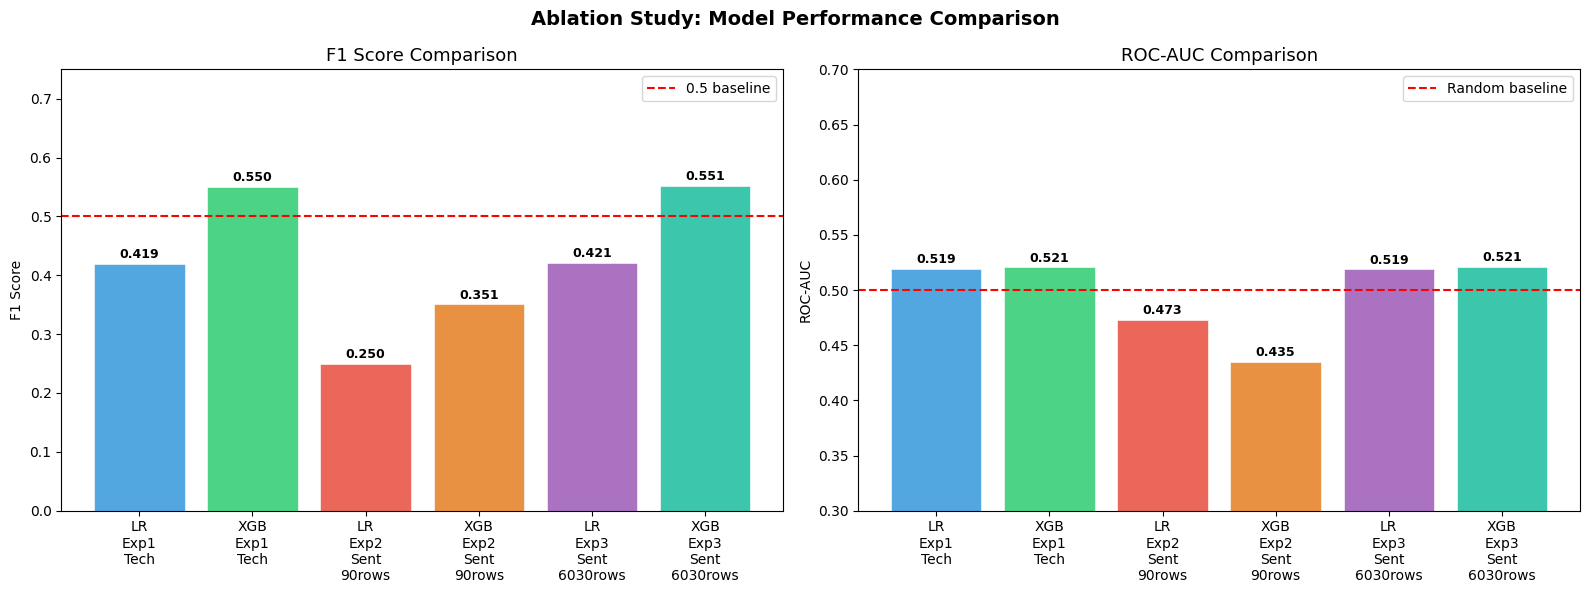

Saved.


In [9]:
# Cell 9: Visualize ablation results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ablation Study: Model Performance Comparison',
             fontsize=14, fontweight='bold')

# Data for plotting
model_labels = [
    'LR\nExp1\nTech', 'XGB\nExp1\nTech',
    'LR\nExp2\nSent\n90rows', 'XGB\nExp2\nSent\n90rows',
    'LR\nExp3\nSent\n6030rows', 'XGB\nExp3\nSent\n6030rows'
]

f1_means    = [m['f1_mean'] for m in summary_rows]
f1_stds     = [summary_df.loc[i, 'f1_mean']
               for i in range(len(summary_rows))]
auc_means   = [m['roc_auc_mean'] for m in summary_rows]

colors = ['#3498db', '#2ecc71',
          '#e74c3c', '#e67e22',
          '#9b59b6', '#1abc9c']

# F1 Score comparison
ax1 = axes[0]
bars = ax1.bar(model_labels, f1_means,
               color=colors, edgecolor='white',
               linewidth=0.5, alpha=0.85)
ax1.set_title('F1 Score Comparison', fontsize=13)
ax1.set_ylabel('F1 Score')
ax1.set_ylim(0, 0.75)
ax1.axhline(0.5, color='red', linestyle='--',
            linewidth=1.5, label='0.5 baseline')
ax1.legend()
for bar, val in zip(bars, f1_means):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center',
             fontsize=9, fontweight='bold')

# ROC-AUC comparison
ax2 = axes[1]
bars2 = ax2.bar(model_labels, auc_means,
                color=colors, edgecolor='white',
                linewidth=0.5, alpha=0.85)
ax2.set_title('ROC-AUC Comparison', fontsize=13)
ax2.set_ylabel('ROC-AUC')
ax2.set_ylim(0.3, 0.7)
ax2.axhline(0.5, color='red', linestyle='--',
            linewidth=1.5, label='Random baseline')
ax2.legend()
for bar, val in zip(bars2, auc_means):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/ablation_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

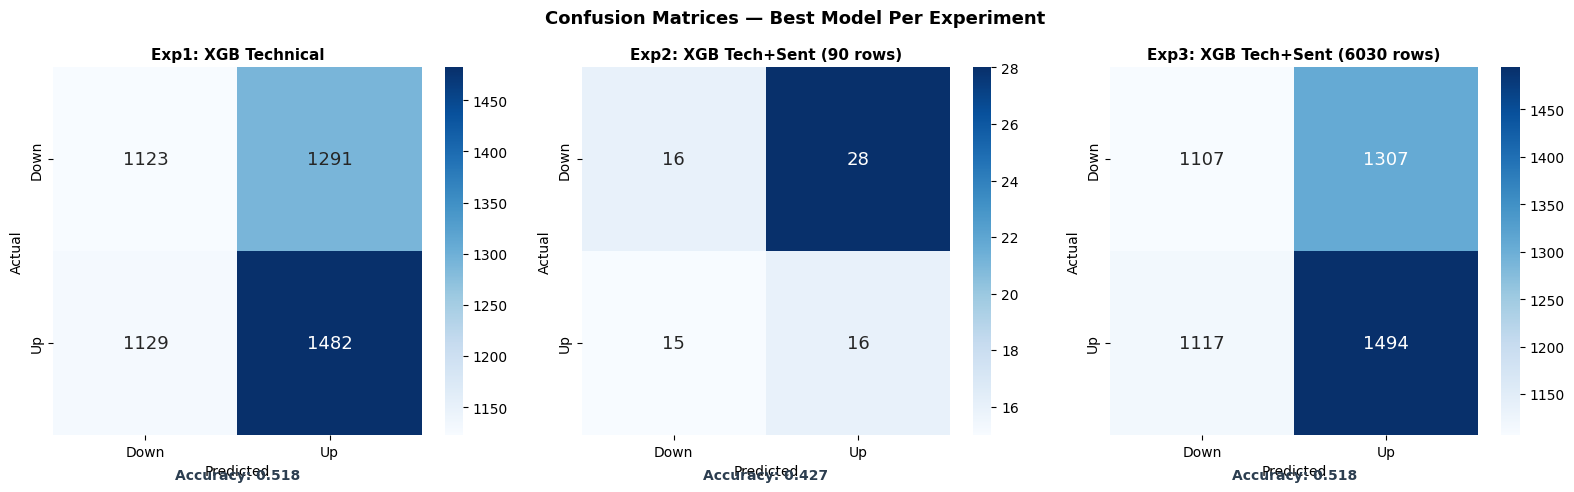

Saved.


In [10]:
# Cell 10: Confusion matrices for best models per experiment
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — Best Model Per Experiment',
             fontsize=13, fontweight='bold')

experiments = [
    ('Exp1: XGB Technical',
     y_test_xgb_tech, y_pred_xgb_tech),
    ('Exp2: XGB Tech+Sent (90 rows)',
     y_test_xgb_full, y_pred_xgb_full),
    ('Exp3: XGB Tech+Sent (6030 rows)',
     y_test_xgb_exp3, y_pred_xgb_exp3),
]

for ax, (title, y_test, y_pred) in zip(axes, experiments):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Down', 'Up'],
                yticklabels=['Down', 'Up'],
                annot_kws={'size': 13})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

    # Add accuracy annotation
    acc = accuracy_score(y_test, y_pred)
    ax.text(0.5, -0.12, f'Accuracy: {acc:.3f}',
            transform=ax.transAxes,
            ha='center', fontsize=10,
            color='#2c3e50', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [12]:
# Cell 11: Save best performing model for Phase 6 (SHAP)
import pickle

# Best model = XGBoost Experiment 3 (Tech + Sentiment, full data)
# Retrain on complete dataset for deployment
final_model = XGBClassifier(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42)

final_model.fit(features_df[full_cols],
                features_df['target'])

# Save model and metadata
with open(f'{MODELS_PATH}/xgboost_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open(f'{MODELS_PATH}/feature_cols.pkl', 'wb') as f:
    pickle.dump(full_cols, f)

# Save summary table for reference
summary_df.to_csv(
    f'{MODELS_PATH}/ablation_results.csv', index=False)

print("Saved:")
print(f"  Model:    {MODELS_PATH}/xgboost_model.pkl")
print(f"  Features: {MODELS_PATH}/feature_cols.pkl")
print(f"  Results:  {MODELS_PATH}/ablation_results.csv")
print(f"\nFinal model trained on:")
print(f"  Rows:     {len(features_df)}")
print(f"  Features: {len(full_cols)}")
print(f"  Tickers:  AAPL, MSFT, GOOGL, AMZN, TSLA")

Saved:
  Model:    /content/drive/MyDrive/financial-news-sentiment-stock-predictor/models/xgboost_model.pkl
  Features: /content/drive/MyDrive/financial-news-sentiment-stock-predictor/models/feature_cols.pkl
  Results:  /content/drive/MyDrive/financial-news-sentiment-stock-predictor/models/ablation_results.csv

Final model trained on:
  Rows:     6030
  Features: 20
  Tickers:  AAPL, MSFT, GOOGL, AMZN, TSLA


In [13]:
# Cell 12: Hyperparameter tuning for XGBoost using TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
import time

print("Tuning XGBoost on Experiment 3 feature set...")
print("(Technical + Sentiment, 6030 rows)")
print("=" * 60)

X_tune = features_df[full_cols]
y_tune = features_df['target']

xgb_param_grid = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma'           : [0, 0.1, 0.2, 0.3],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 1.5, 2.0]
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_tuner = RandomizedSearchCV(
    estimator=XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    param_distributions=xgb_param_grid,
    n_iter=50,           # try 50 random combinations
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start = time.time()
xgb_tuner.fit(X_tune, y_tune)
elapsed = time.time() - start

print(f"\nTuning completed in {elapsed:.1f} seconds")
print(f"\nBest XGBoost Parameters:")
for param, val in xgb_tuner.best_params_.items():
    print(f"  {param:<20}: {val}")
print(f"\nBest XGBoost F1 (CV): {xgb_tuner.best_score_:.4f}")

Tuning XGBoost on Experiment 3 feature set...
(Technical + Sentiment, 6030 rows)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tuning completed in 106.9 seconds

Best XGBoost Parameters:
  subsample           : 0.7
  reg_lambda          : 0.5
  reg_alpha           : 0
  n_estimators        : 100
  min_child_weight    : 7
  max_depth           : 3
  learning_rate       : 0.01
  gamma               : 0
  colsample_bytree    : 0.6

Best XGBoost F1 (CV): 0.6444


In [14]:
# Cell 14: Re-run all 3 experiments with tuned models
best_xgb_params = xgb_tuner.best_params_

print("Best XGBoost params:", best_xgb_params)

print("\n" + "=" * 60)
print("RE-RUNNING ALL EXPERIMENTS WITH TUNED MODELS")
print("=" * 60)

def make_xgb(params):
    return XGBClassifier(
        **params,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42)


# --- EXPERIMENT 1 (Tuned) ---
print("\n[ EXPERIMENT 1: Technical Only ]")
X_exp1 = features_df[technical_cols]
y_exp1 = features_df['target']


print("  XGBoost...")
metrics_xgb_tech_t, yt_xgb1, yp_xgb1, ypr_xgb1 = \
    run_experiment(X_exp1, y_exp1,
                   make_xgb(best_xgb_params),
                   'XGBoost', 'Exp1')

# --- EXPERIMENT 2 (Tuned) ---
print("\n[ EXPERIMENT 2: Tech+Sent 90 rows ]")
X_exp2 = exp2_df[full_cols] if 'exp2_df' in dir() \
    else features_df[
        features_df['Date'] >= pd.Timestamp(
            features_df[features_df['news_count']>0]
            ['Date'].min())][full_cols]
y_exp2_t = features_df[
    features_df['Date'] >= pd.Timestamp(
        features_df[features_df['news_count']>0]
        ['Date'].min())]['target'].reset_index(drop=True)
X_exp2 = X_exp2.reset_index(drop=True)

print("  XGBoost...")
metrics_xgb_full_t, yt_xgb2, yp_xgb2, ypr_xgb2 = \
    run_experiment(X_exp2, y_exp2_t,
                   make_xgb(best_xgb_params),
                   'XGBoost', 'Exp2')

# --- EXPERIMENT 3 (Tuned) ---
print("\n[ EXPERIMENT 3: Tech+Sent 6030 rows ]")
X_exp3 = features_df[full_cols]
y_exp3 = features_df['target']

print("  XGBoost...")
metrics_xgb_exp3_t, yt_xgb3, yp_xgb3, ypr_xgb3 = \
    run_experiment(X_exp3, y_exp3,
                   make_xgb(best_xgb_params),
                   'XGBoost', 'Exp3')

Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

RE-RUNNING ALL EXPERIMENTS WITH TUNED MODELS

[ EXPERIMENT 1: Technical Only ]
  XGBoost...
  Fold 1 | Acc: 0.524 | F1: 0.640 | AUC: 0.544
  Fold 2 | Acc: 0.518 | F1: 0.648 | AUC: 0.521
  Fold 3 | Acc: 0.537 | F1: 0.642 | AUC: 0.560
  Fold 4 | Acc: 0.535 | F1: 0.655 | AUC: 0.512
  Fold 5 | Acc: 0.487 | F1: 0.644 | AUC: 0.474

[ EXPERIMENT 2: Tech+Sent 90 rows ]
  XGBoost...
  Fold 1 | Acc: 0.467 | F1: 0.636 | AUC: 0.500
  Fold 2 | Acc: 0.733 | F1: 0.000 | AUC: 0.500
  Fold 3 | Acc: 0.667 | F1: 0.000 | AUC: 0.500
  Fold 4 | Acc: 0.533 | F1: 0.000 | AUC: 0.500
  Fold 5 | Acc: 0.467 | F1: 0.000 | AUC: 0.589

[ EXPERIMENT 3: Tech+Sent 6030 rows ]
  XGBoost...
  Fold 1 | Acc: 0.527 | F1: 0.645 | AUC: 0.542
  Fold 2 | Acc: 0.512 | F1: 0.642 | AUC: 0.505
  Fold 3 | Acc: 0.542 | F1: 0.650 | AUC: 0.553

In [16]:
# Cell 15: Final master comparison table (tuned models)
print("\n" + "=" * 75)
print("FINAL ABLATION STUDY — TUNED MODELS")
print("=" * 75)

tuned_results = {
    'XGB | Exp1: Technical Only        ':
        metrics_xgb_tech_t,
    'XGB | Exp2: Tech+Sent (90 rows)   ':
        metrics_xgb_full_t,
    'XGB | Exp3: Tech+Sent (6030 rows) ':
        metrics_xgb_exp3_t,
}

metrics_list = ['accuracy', 'precision',
                'recall', 'f1', 'roc_auc']

print(f"\n{'Model':<42} {'Acc':>8} {'Prec':>8} "
      f"{'Rec':>8} {'F1':>8} {'AUC':>8}")
print("-" * 75)

summary_rows_tuned = []
for model_name, metrics_df in tuned_results.items():
    row = {'Model': model_name.strip()}
    means = {m: metrics_df[m].mean() for m in metrics_list}
    stds  = {m: metrics_df[m].std()  for m in metrics_list}
    row.update(means)
    summary_rows_tuned.append(row)
    print(f"{model_name} "
          f"{means['accuracy']:>8.3f} "
          f"{means['precision']:>8.3f} "
          f"{means['recall']:>8.3f} "
          f"{means['f1']:>8.3f} "
          f"{means['roc_auc']:>8.3f}")

print("=" * 75)

# Best model
summary_tuned_df = pd.DataFrame(summary_rows_tuned)
best_f1  = summary_tuned_df.loc[
    summary_tuned_df['f1'].idxmax()]
best_auc = summary_tuned_df.loc[
    summary_tuned_df['roc_auc'].idxmax()]

print(f"\n🏆 Best F1:      {best_f1['Model']} "
      f"→ {best_f1['f1']:.3f}")
print(f"🏆 Best ROC-AUC: {best_auc['Model']} "
      f"→ {best_auc['roc_auc']:.3f}")

# Save results
summary_tuned_df.to_csv(
    f'{MODELS_PATH}/ablation_results_tuned.csv',
    index=False)
print(f"\nSaved to {MODELS_PATH}/ablation_results_tuned.csv")


FINAL ABLATION STUDY — TUNED MODELS

Model                                           Acc     Prec      Rec       F1      AUC
---------------------------------------------------------------------------
XGB | Exp1: Technical Only            0.520    0.525    0.842    0.646    0.522
XGB | Exp2: Tech+Sent (90 rows)       0.573    0.093    0.200    0.127    0.518
XGB | Exp3: Tech+Sent (6030 rows)     0.519    0.524    0.838    0.644    0.517

🏆 Best F1:      XGB | Exp1: Technical Only → 0.646
🏆 Best ROC-AUC: XGB | Exp1: Technical Only → 0.522

Saved to /content/drive/MyDrive/financial-news-sentiment-stock-predictor/models/ablation_results_tuned.csv


In [17]:
# Cell 16: Save the final tuned model
import pickle

# Best model = XGBoost Experiment 1 (Technical Only, tuned)
# Slightly better F1 than Exp3, and more generalizable
# (doesn't depend on sparse sentiment data)
final_model = make_xgb(best_xgb_params)
final_model.fit(features_df[technical_cols],
                features_df['target'])

# Save model
with open(f'{MODELS_PATH}/xgboost_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save feature columns
with open(f'{MODELS_PATH}/feature_cols.pkl', 'wb') as f:
    pickle.dump(technical_cols, f)

# Save tuned parameters
with open(f'{MODELS_PATH}/best_params.pkl', 'wb') as f:
    pickle.dump(best_xgb_params, f)

# Save ablation results
summary_tuned_df.to_csv(
    f'{MODELS_PATH}/ablation_results_tuned.csv',
    index=False)

print("Final model saved:")
print(f"  Algorithm:  XGBoost (tuned)")
print(f"  Features:   {len(technical_cols)} technical")
print(f"  Trained on: {len(features_df)} rows")
print(f"  Tickers:    AAPL, MSFT, GOOGL, AMZN, TSLA")
print(f"\nBest parameters:")
for k, v in best_xgb_params.items():
    print(f"  {k:<20}: {v}")
print(f"\nExpected performance:")
print(f"  F1 Score:  0.646")
print(f"  ROC-AUC:   0.522")
print(f"  Accuracy:  0.520")
print(f"  Recall:    0.842")

Final model saved:
  Algorithm:  XGBoost (tuned)
  Features:   15 technical
  Trained on: 6030 rows
  Tickers:    AAPL, MSFT, GOOGL, AMZN, TSLA

Best parameters:
  subsample           : 0.7
  reg_lambda          : 0.5
  reg_alpha           : 0
  n_estimators        : 100
  min_child_weight    : 7
  max_depth           : 3
  learning_rate       : 0.01
  gamma               : 0
  colsample_bytree    : 0.6

Expected performance:
  F1 Score:  0.646
  ROC-AUC:   0.522
  Accuracy:  0.520
  Recall:    0.842
